<a href="https://colab.research.google.com/github/BintangPancahaya/PCVK26_06_BintangPP/blob/main/Week5_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Bintang Pancahaya P.'
NIM = '244107020115' # ganti dengan NIM Anda
N = int(NIM[-3:])
PARAM = {
'bins' : 2 ** ((N % 4) + 3),
'clip' : round(1.0 + (N % 5) * 0.5, 1),
'tile' : (N % 4) + 2,
'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s:' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Bintang Pancahaya P.
NIM : 244107020115 | N = 115
bins  : 64
clip  : 1.0
tile  : 5
L     : 4
WAKTU : 2026-09-27 21:09:18 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 0f6736fea571f35a


### E. Praktikum


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [30]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

BASE = '/content/drive/MyDrive/PCVK'

### E-1 Percobaan Histogram

In [40]:
# Fungsi bantuan dari modul (D.1 Histogram Image) - dipakai berulang di beberapa percobaan
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)      # 1. siapkan penghitung, isi 0
    for y in range(img.shape[0]):        # 2. telusuri setiap baris
        for x in range(img.shape[1]):    #    dan setiap kolom
            h[img[y, x]] += 1            # 3. tambah 1 sesuai nilai piksel
    return h


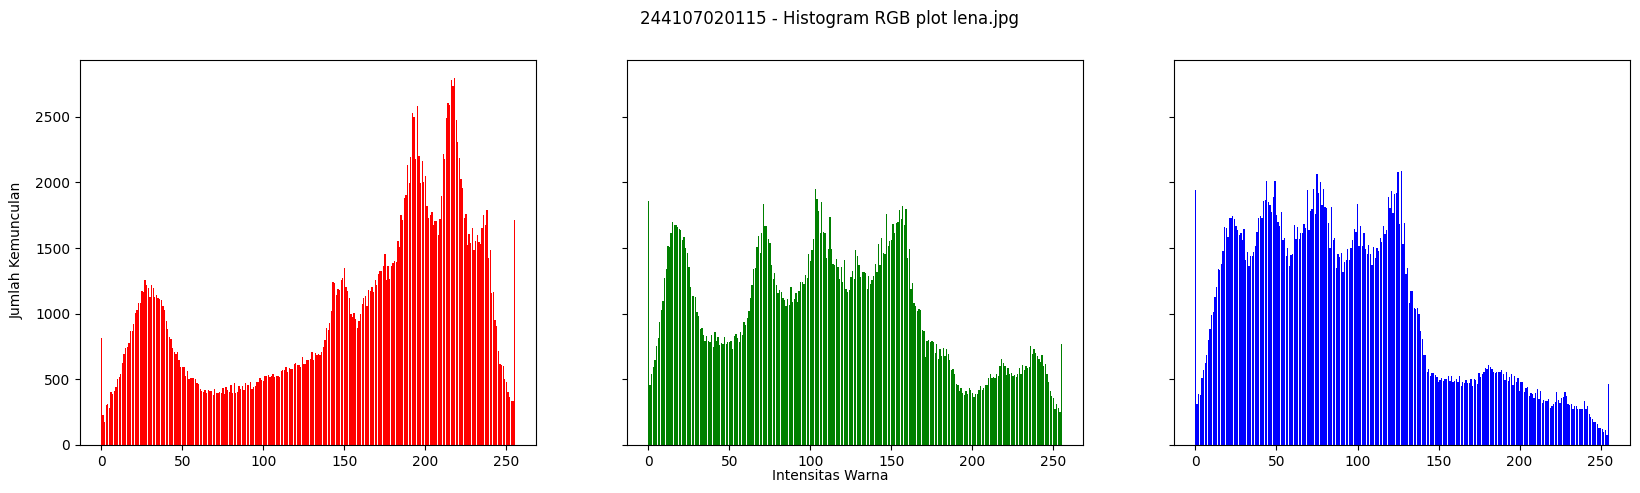

In [31]:
#membuat histogram image (manual)
img = cv.imread(BASE + '/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
    for x in range(0,width) :
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB plot lena.jpg')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()


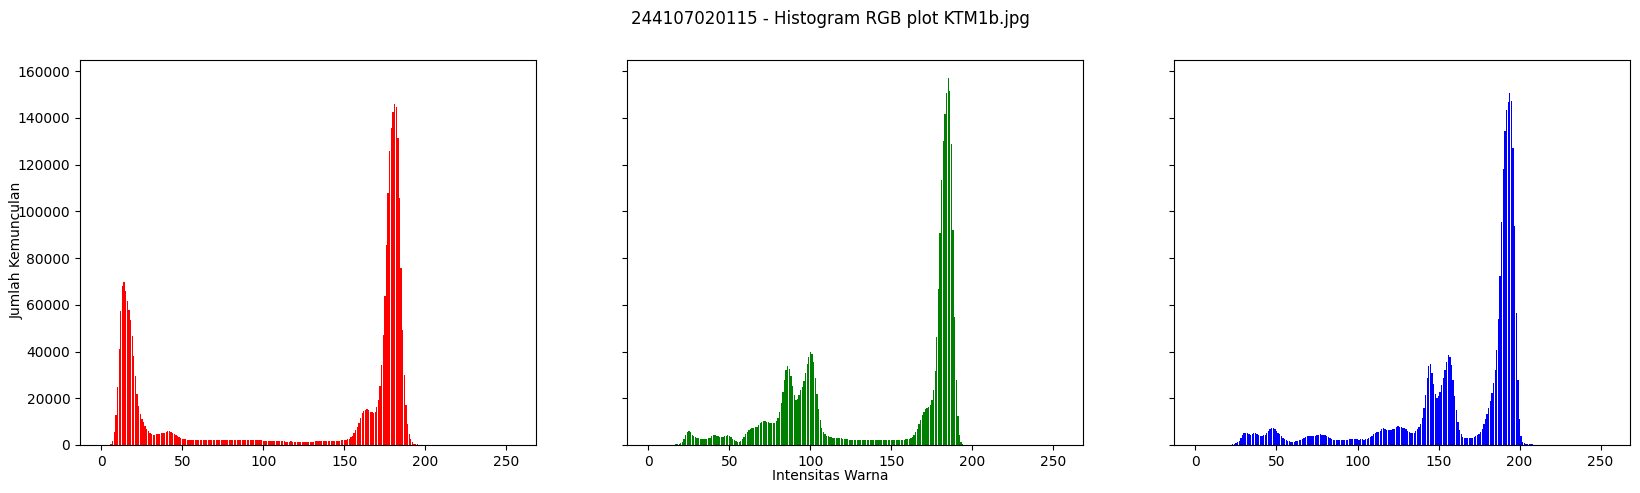

In [33]:
#membuat histogram image (manual)
img = cv.imread(BASE + '/KTM1b.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
    for x in range(0,width) :
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB plot KTM1b.jpg')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()


#### PERTANYAAN PRAKTIKUM
1. Bandingkan histogram NumPy dan cv.calcHist

In [35]:
# Perbandingan lena.jpg
img_lena_gray = cv.imread(BASE + '/lena.jpg', cv.IMREAD_GRAYSCALE)
hist_np_lena, bins = np.histogram(img_lena_gray.flatten(), 256, [0,256])
hist_cv_lena = cv.calcHist([img_lena_gray], [0], None, [256], [0,256]).flatten()

selisih_lena = np.max(np.abs(hist_np_lena - hist_cv_lena))
print('Selisih maksimum histogram lena.jpg:', selisih_lena)

# Perbandingan KTM1b.jpg
img_ktm_gray = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)
hist_np_ktm, _ = np.histogram(img_ktm_gray.flatten(), 256, [0,256])
hist_cv_ktm = cv.calcHist([img_ktm_gray], [0], None, [256], [0,256]).flatten()

selisih_ktm = np.max(np.abs(hist_np_ktm - hist_cv_ktm))
print('Selisih maksimum histogram KTM1b.jpg:', selisih_ktm)

Selisih maksimum histogram lena.jpg: 0.0
Selisih maksimum histogram KTM1b.jpg: 0.0


2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a - KTM1d


/tmp/ipykernel_4149/1558695687.py:20: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_gray.flatten(), 256, [0,256], color='r', density=True, alpha=0.6, label='Histogram Ternormalisasi')


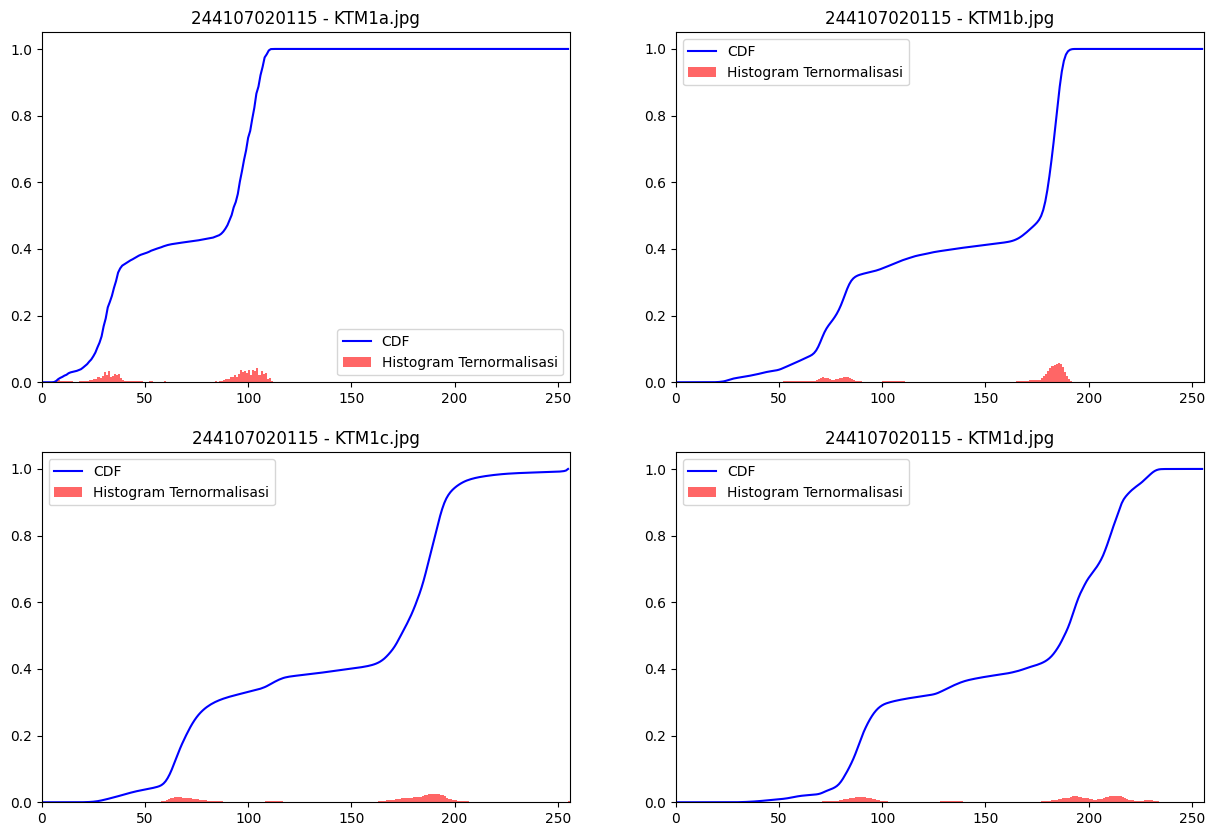

In [36]:
plt.figure(figsize=(15, 10))

citra_ktm = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']

for i in range(4):
    img_gray = cv.imread(BASE + '/' + citra_ktm[i], cv.IMREAD_GRAYSCALE)

    # Histogram manual
    h = np.zeros(256, dtype=np.int64)
    H, W = img_gray.shape
    for y in range(H):
        for x in range(W):
            h[img_gray[y, x]] += 1

    p = h / (H * W) # normalisasi
    cdf = np.cumsum(p)

    plt.subplot(2, 2, i+1)
    plt.plot(cdf, color='b', label='CDF')
    plt.hist(img_gray.flatten(), 256, [0,256], color='r', density=True, alpha=0.6, label='Histogram Ternormalisasi')
    plt.xlim([0, 256])
    plt.title(NIM + ' - ' + citra_ktm[i])
    plt.legend()

plt.show()


3. Histogram KTM1b.jpg dengan bin sejumlah PARAM['bins'] vs 256 bin

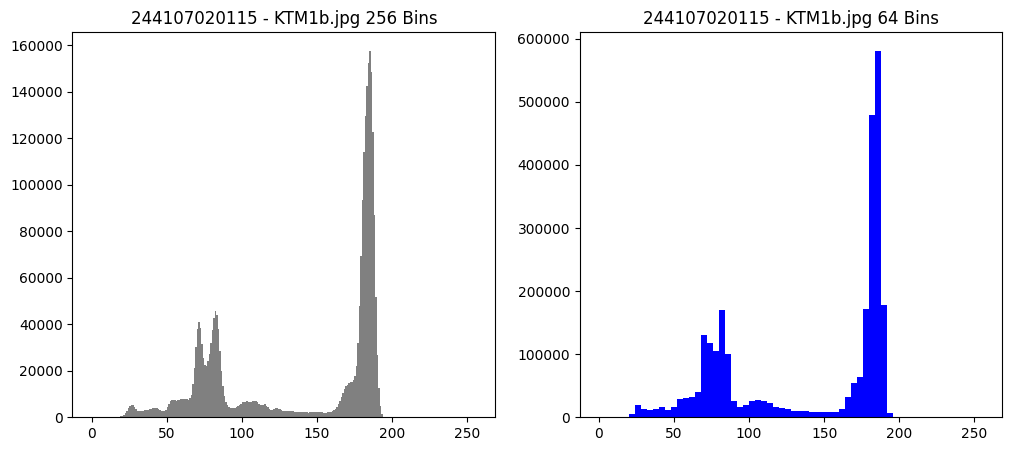

In [37]:
img_ktm1b = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 5))

# Plot dengan 256 bin
plt.subplot(1, 2, 1)
plt.hist(img_ktm1b.flatten(), bins=256, range=[0,256], color='gray')
plt.title(NIM + ' - KTM1b.jpg 256 Bins')

# Plot dengan PARAM['bins']
plt.subplot(1, 2, 2)
plt.hist(img_ktm1b.flatten(), bins=PARAM['bins'], range=[0,256], color='blue')
plt.title(NIM + ' - KTM1b.jpg ' + str(PARAM['bins']) + ' Bins')

plt.show()

### E-2 PERCOBAAN HISTOGRAM EQUALIZATION
#### 1. Histogram Equalization Manual


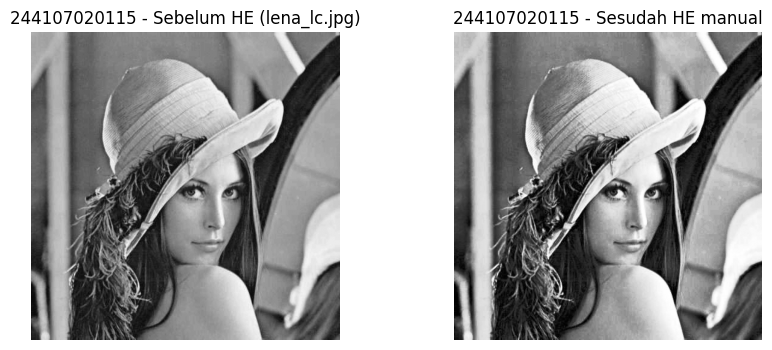

In [41]:
# Langkah 1 - Histogram Equalization manual (flowchart D.2) - TAHAP 1: lena_lc.jpg
berkas = BASE + '/lena_lc.jpg'
bgr = cv.imread(berkas)
gray = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)

L = 256
h = histogram_manual(gray, L)
p = h / gray.size                          # normalisasi, jumlahnya = 1
cdf = np.cumsum(p)                         # distribusi kumulatif
transform = np.round((L - 1) * cdf)        # transform function G(zq)
transform = transform.astype(np.uint8)

gray_he_manual = transform[gray]           # transformasi kembali dalam bentuk citra

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title(NIM + ' - Sebelum HE (lena_lc.jpg)')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(gray_he_manual, cmap='gray')
plt.title(NIM + ' - Sesudah HE manual')
plt.axis('off')
plt.show()


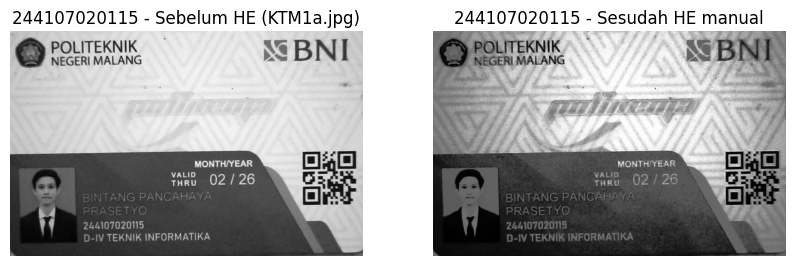

In [42]:
# Langkah 1 - Histogram Equalization manual - TAHAP 2: KTM1a.jpg (hasil akuisisi ruangan gelap)
berkas = BASE + '/KTM1a.jpg'
bgr = cv.imread(berkas)
gray = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)

L = 256
h = histogram_manual(gray, L)
p = h / gray.size
cdf = np.cumsum(p)
transform = np.round((L - 1) * cdf)
transform = transform.astype(np.uint8)

gray_he_manual_ktm = transform[gray]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title(NIM + ' - Sebelum HE (KTM1a.jpg)')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(gray_he_manual_ktm, cmap='gray')
plt.title(NIM + ' - Sesudah HE manual')
plt.axis('off')
plt.show()


In [44]:
# Langkah 2 - Ekualisasi memakai cv2.equalizeHist (lengkapi potongan kode modul) - TAHAP 1: lena_lc.jpg
berkas = BASE + '/lena_lc.jpg'
image = cv.imread(berkas)

b, g, r = cv.split(image)

b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)

image_equalized = cv.merge([b_equalized, g_equalized, r_equalized])
gray_equalized_cv = cv.cvtColor(image_equalized, cv.COLOR_BGR2GRAY)

selisih_manual_cv = np.max(np.abs(gray_he_manual.astype(np.int16) - gray_equalized_cv.astype(np.int16)))
print(NIM, '- lena_lc.jpg')
print('Selisih maksimum manual vs cv2.equalizeHist :', selisih_manual_cv)


244107020115 - lena_lc.jpg
Selisih maksimum manual vs cv2.equalizeHist : 27


In [45]:
# Langkah 2 - Ekualisasi memakai cv2.equalizeHist - TAHAP 2: KTM1a.jpg
berkas = BASE + '/KTM1a.jpg'
image = cv.imread(berkas)

b, g, r = cv.split(image)

b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)

image_equalized = cv.merge([b_equalized, g_equalized, r_equalized])
gray_equalized_cv_ktm = cv.cvtColor(image_equalized, cv.COLOR_BGR2GRAY)

selisih_manual_cv_ktm = np.max(np.abs(gray_he_manual_ktm.astype(np.int16) - gray_equalized_cv_ktm.astype(np.int16)))
print(NIM, '- KTM1a.jpg')
print('Selisih maksimum manual vs cv2.equalizeHist :', selisih_manual_cv_ktm)


244107020115 - KTM1a.jpg
Selisih maksimum manual vs cv2.equalizeHist : 57


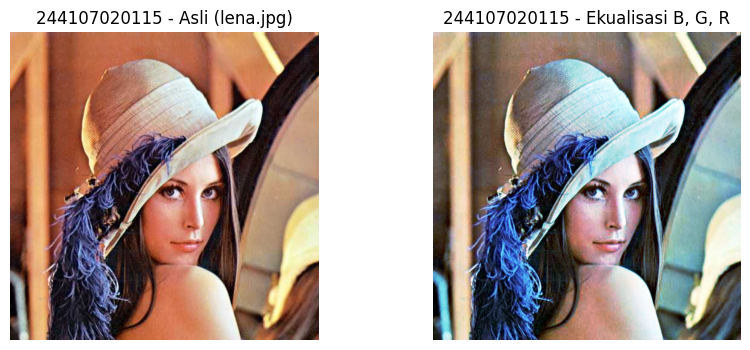

In [46]:
# Langkah 3 - Ekualisasi citra berwarna, cara 1: tiap kanal B, G, R diekualisasi sendiri-sendiri - TAHAP 1: lena.jpg
berkas = BASE + '/lena.jpg'   # tahap 1
bgr    = cv.imread(berkas)

# cara 1: tiap kanal diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Asli (lena.jpg)')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Ekualisasi B, G, R')
plt.axis('off')
plt.show()


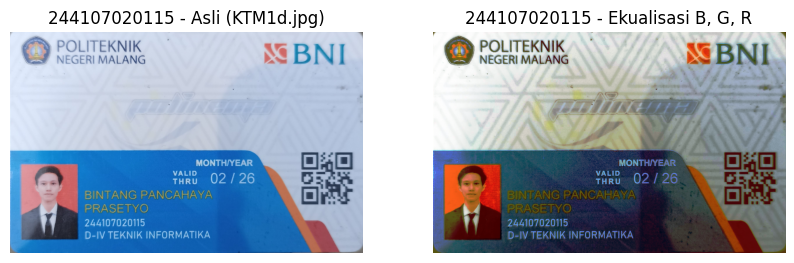

In [47]:
# Langkah 3 - cara 1 (kanal B, G, R) - TAHAP 2: KTM1d.jpg
berkas = BASE + '/KTM1d.jpg'   # tahap 2
bgr    = cv.imread(berkas)

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Asli (KTM1d.jpg)')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Ekualisasi B, G, R')
plt.axis('off')
plt.show()


In [48]:
# Langkah 4 - cara 2: hanya kanal terang yang diekualisasi (YCrCb, HSV, LAB) - KTM1d.jpg
# cara 2: hanya kanal terang yang diekualisasi
ycrcb    = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# varian setara pada ruang warna lain
hsv       = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab      = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b  = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)


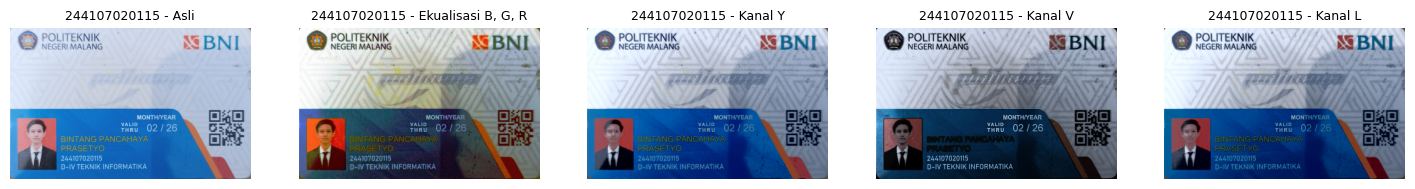

In [49]:
# Langkah 4 - tampilkan kelima citra berdampingan
judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()


In [50]:
# Langkah 4 - ukur pergeseran kanal Hue terhadap citra asli
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d  = np.abs(h1 - h2)
    d  = np.minimum(d, 180 - d)      # Hue melingkar 0-179
    return d.mean()

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
                                    cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))


Cara                    geser Hue (der)    rerata terang
Asli                               0.00            161.2
Ekualisasi B, G, R                68.75            129.0
Kanal Y                            3.19            131.1
Kanal V                            1.20            108.2
Kanal L                            4.29            122.5


**Tabel & Jawaban Langkah 4:**

| Cara ekualisasi | Rata-rata pergeseran Hue (derajat) | Rerata kecerahan sesudah |
|---|---|---|
| Citra asli | - |161.2 |
| Ekualisasi kanal B, G, R |68.75 |129.0 |
| Kanal Y (YCrCb) |3.19 |131.1 |
| Kanal V (HSV) |1.20 |108.2 |
| Kanal L (LAB) |4.29 |122.5 |

1. Cara mana yang menghasilkan pergeseran Hue paling besar?
Ekualisasi kanal B, G, R (per-kanal warna), dengan pergeseran 68.75°. Ini jauh lebih besar daripada tiga cara lainnya (yang semuanya di bawah 5°). Penyebabnya masuk akal: saat B, G, R diekualisasi sendiri‑sendiri, rasio antar kanal (yang menentukan jenis warna/Hue) ikut berubah drastis, karena tiap kanal punya histogram dan fungsi transformasi yang berbeda‑beda. Sedangkan cara kanal‑terang (Y/V/L) memang dirancang supaya hanya kecerahan yang berubah dan rasio warna R:G:B relatif dipertahankan.

2. Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis nol?
Karena proses konversi ruang warna bolak‑balik (BGR → YCrCb/HSV/LAB → BGR) tidak lossless secara numerik. Nilai kanal Y/V/L yang baru (hasil equalizeHist) adalah bilangan bulat hasil pembulatan, lalu saat digabung kembali dengan Cr/Cb (atau H/S, atau A/B) dan dikonversi balik ke BGR, hasil R, G, B yang didapat juga dibulatkan dan dipotong (clip) ke rentang 0–255. Pembulatan berulang ini membuat rasio antar kanal R:G:B sedikit bergeser dari rasio aslinya, walau secara teori seharusnya tetap sama — sehingga Hue ikut bergeser sedikit (di kasusmu: 1.2°–4.3°), meski jauh lebih kecil daripada cara B,G,R terpisah.

3. Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM kamu?
Kanal V (HSV), karena pergeserannya paling kecil (1.20°) artinya warna asli KTM (misalnya warna biru logo Polinema, warna kartu BNI, warna kulit di foto) paling minim berubah dibanding dua kanal lainnya. Kamu bisa perkuat argumen ini dengan menunjukkan area tertentu di citra (misalnya logo atau foto wajah) dan membandingkan secara visual apakah warnanya terlihat masih natural di hasil kanal V dibanding hasil kanal Y atau L — kalau terlihat paling mendekati warna aslinya, itu jadi bukti visual pendukung.

4. Bandingkan CLAHE vs ekualisasi biasa pada kanal terang
Ini belum ada di outputmu — kamu perlu jalankan dulu cell "Pertanyaan E2 No. 2a" (CLAHE) tapi diterapkan ke salah satu kanal terang, bukan langsung ke grayscale. Tambahkan cell baru seperti ini (pakai kanal V karena itu yang terbaik di poin 3):

In [51]:
# Langkah 4 lanjutan - CLAHE pada kanal terang (V) dibandingkan equalizeHist biasa
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
v_clahe = clahe.apply(v)
he_v_clahe = cv.cvtColor(cv.merge([h, sat, v_clahe]), cv.COLOR_HSV2BGR)

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
print('%-22s %16.2f %16.1f' % ('Kanal V (equalizeHist)', geser_hue(bgr, he_v) * 2,
                                cv.cvtColor(he_v, cv.COLOR_BGR2GRAY).mean()))
print('%-22s %16.2f %16.1f' % ('Kanal V (CLAHE)', geser_hue(bgr, he_v_clahe) * 2,
                                cv.cvtColor(he_v_clahe, cv.COLOR_BGR2GRAY).mean()))

Cara                    geser Hue (der)    rerata terang
Kanal V (equalizeHist)             1.20            108.2
Kanal V (CLAHE)                    0.28            154.9


### Pertanyaan Praktikum E2

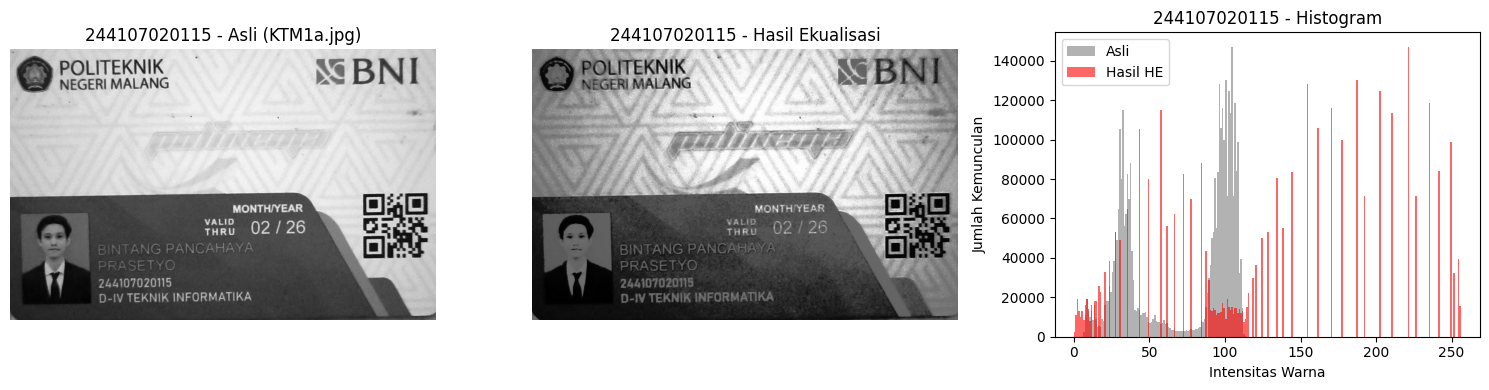

In [52]:
# Pertanyaan E2 No. 1a & 1b - Ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg (grayscale)
gray = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)

L = 256
h = histogram_manual(gray, L)
p = h / gray.size
cdf = np.cumsum(p)
transform = np.round((L - 1) * cdf).astype(np.uint8)
gray_he = transform[gray]

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title(NIM + ' - Asli (KTM1a.jpg)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gray_he, cmap='gray')
plt.title(NIM + ' - Hasil Ekualisasi')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.hist(gray.ravel(), bins=256, range=(0, 256), color='gray', alpha=0.6, label='Asli')
plt.hist(gray_he.ravel(), bins=256, range=(0, 256), color='red', alpha=0.6, label='Hasil HE')
plt.title(NIM + ' - Histogram')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.legend()

plt.tight_layout()
plt.show()


In [53]:
# Pertanyaan E2 No. 1c - Hitung PSNR antara citra asli dan citra hasil ekualisasi
mse = np.mean((gray.astype(np.float64) - gray_he.astype(np.float64)) ** 2)
psnr = 10 * math.log10((255.0 ** 2) / mse)

print(NIM, '- KTM1a.jpg')
print('MSE  :', mse)
print('PSNR :', psnr, 'dB')


244107020115 - KTM1a.jpg
MSE  : 5406.725645206622
PSNR : 10.801460282436164 dB


**Jawaban No. 1c:**
PSNR bisa turun walau citra terlihat lebih jelas karena PSNR hanya
mengukur selisih nilai piksel terhadap citra asli (mirip MSE), bukan seberapa mudah informasi pada
citra dibaca oleh mata manusia. Histogram Equalization sengaja mengubah nilai piksel secara signifikan
agar kontras menyebar, sehingga selisih terhadap citra asli menjadi besar dan PSNR rendah, padahal
keterbacaan visual justru meningkat.


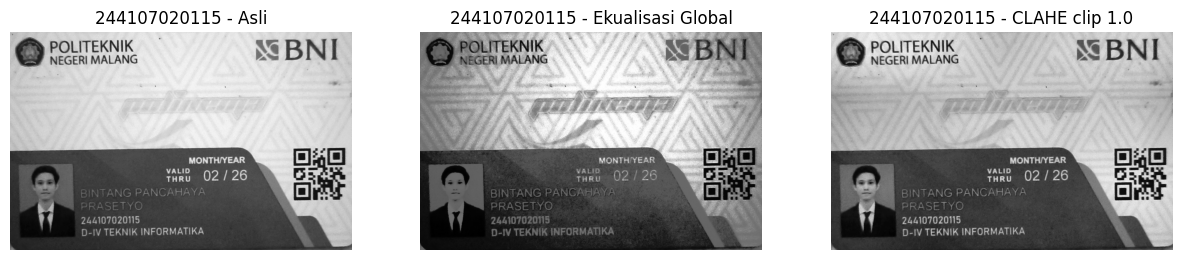

In [54]:
# Pertanyaan E2 No. 2a - CLAHE pada KTM1a.jpg dengan clipLimit dan tileGridSize sesuai PARAM
gray = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)

clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
gray_clahe = clahe.apply(gray)
gray_global = cv.equalizeHist(gray)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title(NIM + ' - Asli')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gray_global, cmap='gray')
plt.title(NIM + ' - Ekualisasi Global')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(gray_clahe, cmap='gray')
plt.title(NIM + ' - CLAHE clip ' + str(PARAM['clip']))
plt.axis('off')

plt.show()


**Jawaban No. 2a:**
Hasil ekualisasi lokal menggunakan CLAHE membuat NIM dan nama pada KTM menjadi jauh lebih terbaca dibandingkan Ekualisasi Global. Hal ini terjadi karena Ekualisasi Global meningkatkan kontras secara keseluruhan di seluruh citra, sehingga pola garis/watermark latar belakang ikut menjadi sangat tebal dan menyamarkan bentuk teks. Sebaliknya, CLAHE membagi citra ke dalam blok-blok kecil (tiles) serta membatasi lonjakan kontras (clipLimit), sehingga pencahayaan di area nama dan NIM terdistribusi lebih seimbang dan bersih tanpa memicu noise atau efek over-exposure yang mengganggu penglihatan.


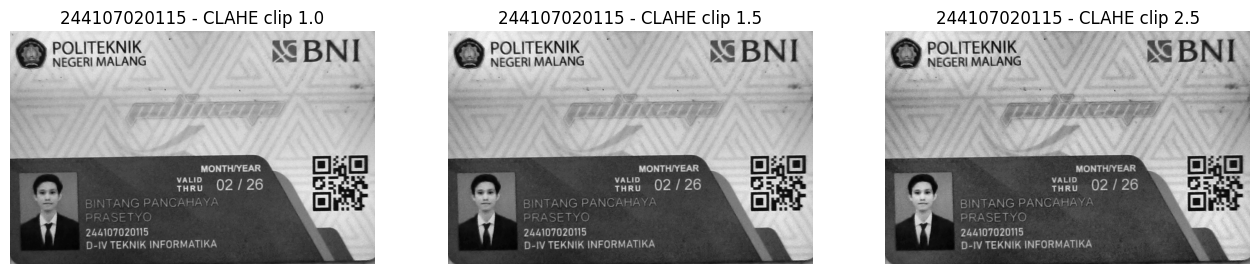

In [55]:
# Pertanyaan E2 No. 2b - Coba tiga nilai clipLimit lain di sekitar nilai PARAM['clip']
nilai_clip_lain = [PARAM['clip'] - 0.5, PARAM['clip'] + 0.5, PARAM['clip'] + 1.5]

plt.figure(figsize=(16, 4))
for i, clip_val in enumerate(nilai_clip_lain, 1):
    clip_val = max(clip_val, 1.0)   # clipLimit minimal 1.0
    clahe_i = cv.createCLAHE(clipLimit=clip_val, tileGridSize=(PARAM['tile'], PARAM['tile']))
    hasil_i = clahe_i.apply(gray)

    plt.subplot(1, 3, i)
    plt.imshow(hasil_i, cmap='gray')
    plt.title(NIM + ' - CLAHE clip ' + str(round(clip_val, 1)))
    plt.axis('off')

plt.show()


Jawaban No. 2b: Nilai clipLimit terbaik adalah 1.0 (atau 1.5). Nilai 1.0–1.5 memberikan tingkat kontras yang paling seimbang: teks NIM dan nama terlihat jelas dan tajam tanpa memicu peningkatan noise berlebihan. Ketika clipLimit dinaikkan ke 2.5, kontras lokal dipaksa meningkat lebih tinggi sehingga noise berupa bintik-bintik kasar dan keabu-abuan mulai menonjol secara signifikan

## E-3 TUGAS PRAKTIKUM DITHERING

In [56]:
# Fungsi Floyd-Steinberg dari modul (D.3 Image Dithering)
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step   # warna palet terdekat
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:                     img[y,   x+1] += error * 7 / 16
            if x > 0 and y+1 < H:              img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:                      img[y+1, x  ] += error * 5 / 16
            if x + 1 < W and y+1 < H:          img[y+1, x+1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)


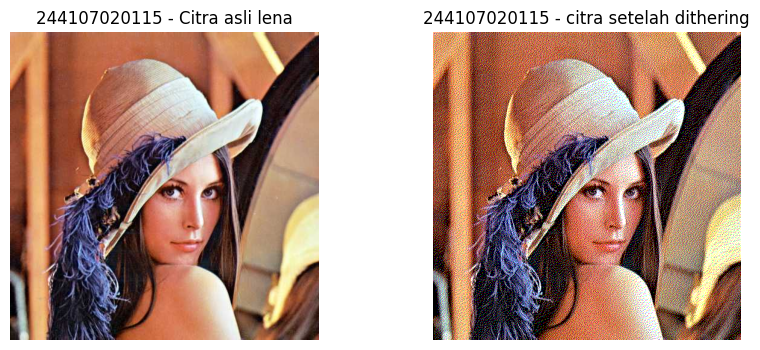

In [57]:
# Langkah 1 - Dithering Floyd-Steinberg citra berwarna - TAHAP 1: lena.jpg (L = 2, default)
bgr = cv.imread(BASE + '/lena.jpg')

# Catatan modul: untuk citra berwarna, floyd_steinberg dijalankan tiga kali, sekali untuk tiap kanal B, G, R
b, g, r = cv.split(bgr)
b_dither = floyd_steinberg(b)
g_dither = floyd_steinberg(g)
r_dither = floyd_steinberg(r)
bgr_dither = cv.merge([b_dither, g_dither, r_dither])

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Citra asli lena')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(bgr_dither, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - citra setelah dithering')
plt.axis('off')
plt.show()


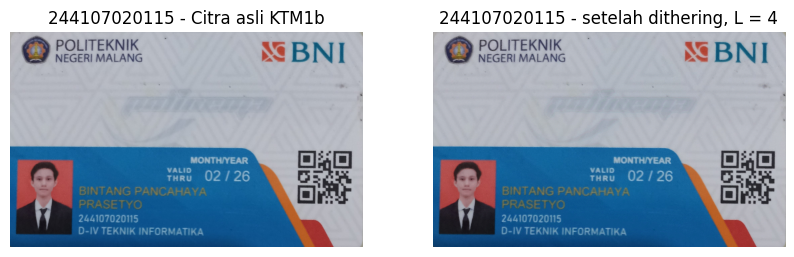

In [58]:
# Langkah 1 - TAHAP 2: KTM1b.jpg dengan jumlah level PARAM['L']
bgr = cv.imread(BASE + '/KTM1b.jpg')

b, g, r = cv.split(bgr)
b_dither = floyd_steinberg(b, PARAM['L'])
g_dither = floyd_steinberg(g, PARAM['L'])
r_dither = floyd_steinberg(r, PARAM['L'])
bgr_dither_ktm = cv.merge([b_dither, g_dither, r_dither])

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Citra asli KTM1b')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(bgr_dither_ktm, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - setelah dithering, L = ' + str(PARAM['L']))
plt.axis('off')
plt.show()


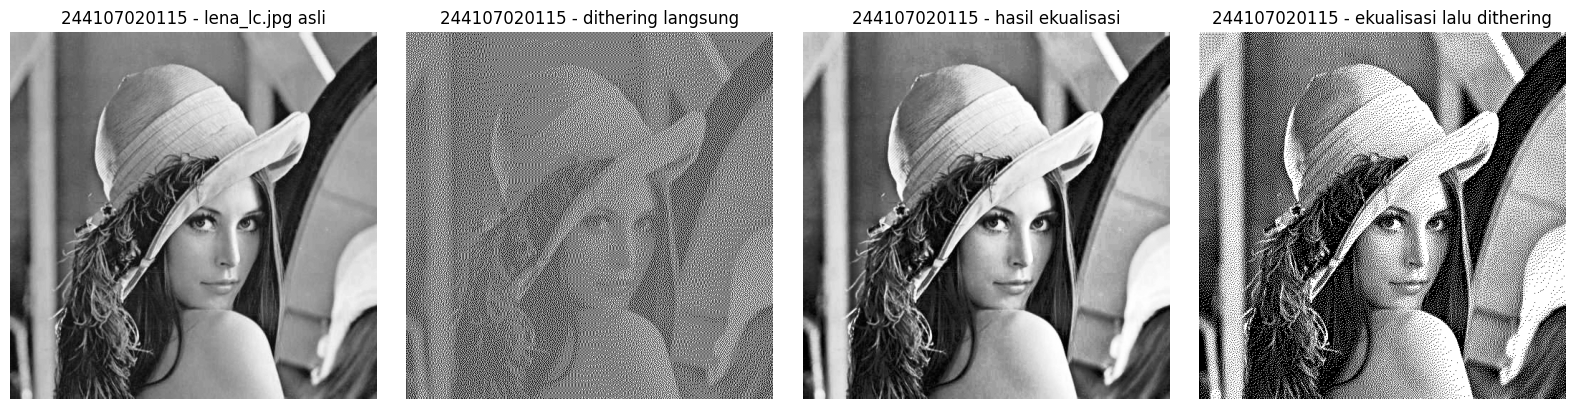

In [59]:
# Langkah 2 - grayscale + HE + dithering, dibandingkan dengan dithering langsung - TAHAP 1: lena_lc.jpg
gray = cv.imread(BASE + '/lena_lc.jpg', cv.IMREAD_GRAYSCALE)

dither_langsung = floyd_steinberg(gray)

gray_he = cv.equalizeHist(gray)
dither_setelah_he = floyd_steinberg(gray_he)

plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.imshow(gray, cmap='gray')
plt.title(NIM + ' - lena_lc.jpg asli')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(dither_langsung, cmap='gray')
plt.title(NIM + ' - dithering langsung')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(gray_he, cmap='gray')
plt.title(NIM + ' - hasil ekualisasi')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(dither_setelah_he, cmap='gray')
plt.title(NIM + ' - ekualisasi lalu dithering')
plt.axis('off')

plt.tight_layout()
plt.show()


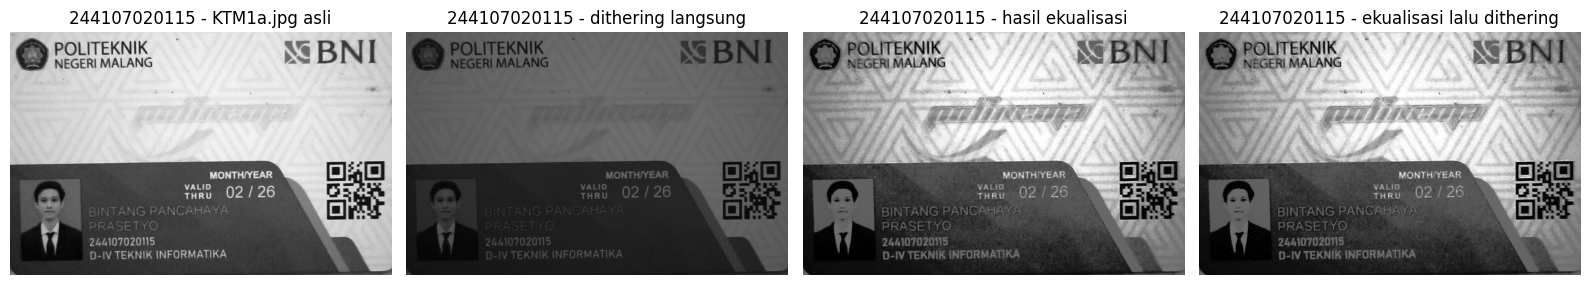

In [60]:
# Langkah 2 - TAHAP 2: KTM1a.jpg
gray = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)

dither_langsung_ktm = floyd_steinberg(gray)

gray_he_ktm = cv.equalizeHist(gray)
dither_setelah_he_ktm = floyd_steinberg(gray_he_ktm)

plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.imshow(gray, cmap='gray')
plt.title(NIM + ' - KTM1a.jpg asli')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(dither_langsung_ktm, cmap='gray')
plt.title(NIM + ' - dithering langsung')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(gray_he_ktm, cmap='gray')
plt.title(NIM + ' - hasil ekualisasi')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(dither_setelah_he_ktm, cmap='gray')
plt.title(NIM + ' - ekualisasi lalu dithering')
plt.axis('off')

plt.tight_layout()
plt.show()


**Jawaban Langkah 2:**  
Urutan yang menghasilkan teks pada KTM jauh lebih terbaca adalah ekualisasi histogram terlebih dahulu, lalu dithering. Pada citra KTM1a.jpg yang kondisinya gelap, penerapan dithering langsung tanpa ekualisasi membuat rentang kuantisasi menggabungkan teks dan latar belakang yang sama-sama redup ke level intensitas yang sama, sehingga tulisan nama, NIM, dan prodi menjadi menyatu dengan background serta sulit dibaca.